In [94]:
#Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [95]:
#Dados
zonas = pd.read_csv('./Zonas.csv')
eleitorado = pd.read_csv('./cruzamento_eleitorado_escolaridade.csv')

In [96]:
#Visualizando Eleitorado
display(eleitorado)

,Zona,Escolaridade,Eleitorado,Com biometria,Com biometria (%),Com nome social,Com deficiência,Data de carga
0,1,ANALFABETO,233,194,"0,8326",0,21,2022-07-11 22:32:34
1,1,ENSINO FUNDAMENTAL COMPLETO,2185,2038,"0,9327",2,43,2022-07-11 22:32:34
2,1,ENSINO FUNDAMENTAL INCOMPLETO,5586,5293,"0,9475",5,96,2022-07-11 22:32:34
3,1,ENSINO MÉDIO COMPLETO,19699,18461,"0,9372",18,195,2022-07-11 22:32:34
4,1,ENSINO MÉDIO INCOMPLETO,6294,4911,"0,7803",7,57,2022-07-11 22:32:34
...,...,...,...,...,...,...,...,...
148,19,ENSINO MÉDIO COMPLETO,51589,48505,"0,9402",26,430,2022-07-11 22:32:34
149,19,ENSINO MÉDIO INCOMPLETO,20808,16708,"0,803",22,152,2022-07-11 22:32:34
150,19,LÊ E ESCREVE,4287,4118,"0,9606",1,227,2022-07-11 22:32:34
151,19,SUPERIOR COMPLETO,11073,10888,"0,9833",0,65,2022-07-11 22:32:34


In [97]:
# Especifique o nome do arquivo Excel que você deseja criar
nome_do_arquivo = 'Escolaridade_por_zona.xlsx'

# Exportar o DataFrame para o arquivo Excel
eleitorado.to_excel(nome_do_arquivo, index=False)

In [98]:
#Visualizar Zonas
display(zonas)

,ZONA,MUNICÍPIO,NOME_LOCAL,ENDEREÇO_LOCAL,BAIRRO_LOCAL,CEP,NÚMERO_DAS_SEÇÕES,SEÇÕES,APTOS
0,1,SALVADOR,CABANA DA BARRA,AV. AFONSO CELSO 1 - ZONA URBANA,BARRA,40140080,"40,41,272,275,320",5,2202
1,1,SALVADOR,BAHIA BRITSH CLUB (CLUBE INGLÊS),RUA BANCO DOS INGLESES 20 - ZONA URBANA,CAMPO GRANDE,40080040,"61,70,71,72,73,74",6,2071
2,1,SALVADOR,COLÉGIO ESTADUAL DEPUTADO MANOEL NOVAES,"AV. ARAÚJO PINHO, 30 - ZONA URBANA",CANELA,40110150,"42,43,44,45,75,76,77,78,92,93,94,95,96,103,123...",21,6584
3,1,SALVADOR,PAVILHÃO DE AULAS DO CANELA - UFBA,"RUA REITOR MIGUEL CALMON, S/N- ZONA URBANA",CANELA,40110904,"11,12,13,14,15,16,80,81,82,83,84,220,221",13,3987
4,1,SALVADOR,ESCOLA DE BELAS ARTES,AV. ARAÚJO PINHO 212 - ZONA URBANA,CANELA,40110150,"24,35,36,37,38,89,90,91",8,2695
...,...,...,...,...,...,...,...,...,...
469,19,SALVADOR,ESCOLA MUNICIPAL MARIA ANTONIETA ALFARANO,"LARGO DO CABO VERDE, S/N - ZONA URBANA",CAJAZEIRAS XI,41245130,"476,477,478,479,521,802",6,2425
470,19,SALVADOR,ESCOLA MUNICIPAL DE CAJAZEIRAS XI,"RUA JORNALISTA JOSÉ CURVELLO, 419 (RETORNO DO ...",CAJAZEIRAS XI,41330030,"480,482,483,484,485,486,487,488,489,490,491,517",12,5106
471,19,SALVADOR,COLÉGIO ESTADUAL DONA MORA GUIMARÃES,"RUA C, QUADRA C, SETOR 2, FAZENDA GRANDE I - Z...",CAJAZEIRAS,41340100,"492,493,494,495,496,497,498,499,500,501,502,50...",16,7153
472,19,SALVADOR,COLÉGIO ESTADUAL DE NOVA ESPERANÇA,"RUA VITÓRIA DA CEASA, S/N - ZONA URBANA",CEASA,41400025,"272,533,547,551,801,809",6,2546


In [99]:
########### ZONA #####################

In [100]:
#Todas as zonas eleitorias de Salvador
valores_zona= zonas['ZONA'].unique()
valores_zona

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19])

In [101]:
#Zona
#1° passo - Agrupar as zonas que tem o mesmo numero aos bairros que pertencem
# Agrupar bairros por zona e remover duplicatas
bairros_agrupados = zonas.groupby("ZONA")["BAIRRO_LOCAL"].unique().apply(list).reset_index()

# Criar um novo DataFrame com os resultados
zonas_eleitorais = pd.DataFrame({
    "Zona": bairros_agrupados["ZONA"],
    "Bairros_Agrupados": bairros_agrupados["BAIRRO_LOCAL"]
})

# Exibindo o novo DataFrame com os resultados
display(zonas_eleitorais)

,Zona,Bairros_Agrupados
0,1,"[BARRA, CAMPO GRANDE, CANELA, GRAÇA, CHAME-CHA..."
1,2,"[RIO VERMELHO, PARQUE SÃO BRÁS, ONDINA, FEDERA..."
2,3,"[PERO VAZ, IAPI, FAZENDA GRANDE DO RETIRO, PAU..."
3,4,"[PERIPERI, COUTOS, PARIPE, FAZENDA COUTOS, TUB..."
4,5,"[CABULA, SÃO GONÇALO, SÃO GONÇALO DO RETIRO, M..."
5,6,"[BROTAS, CAMPINAS DE BROTAS, BONOCÔ, BOA VISTA..."
6,7,"[NAZARÉ, BARRIS, BARBALHO, SAÚDE, PITANGUEIRAS..."
7,8,"[CAJAZEIRAS IV, CAJAZEIRAS V, CAJAZEIRAS VI, C..."
8,9,"[ITAPAGIPE, RIBEIRA, BOA VIAGEM, BONFIM, URUGU..."
9,10,"[IMBUÍ, BOCA DO RIO, BAIRRO DA PAZ, PITUAÇU, P..."


In [102]:
# Especifique o nome do arquivo Excel que você deseja criar
nome_do_arquivo = 'Zonas_agrupadas.xlsx'

# Exportar o DataFrame para o arquivo Excel
zonas_eleitorais.to_excel(nome_do_arquivo, index=False)

In [103]:
########### Escolaridade ##############

In [104]:
#Escolaridades - Tipos
escolaridades= eleitorado['Escolaridade'].unique()
escolaridades

array(['ANALFABETO', 'ENSINO FUNDAMENTAL COMPLETO',
       'ENSINO FUNDAMENTAL INCOMPLETO', 'ENSINO MÉDIO COMPLETO',
       'ENSINO MÉDIO INCOMPLETO', 'LÊ E ESCREVE', 'NÃO INFORMADO',
       'SUPERIOR COMPLETO', 'SUPERIOR INCOMPLETO'], dtype=object)

In [105]:

# Dicionário para armazenar as somas
somas = {}

# Calculando a soma do eleitorado para cada escolaridade
for escolaridade in escolaridades:
    soma = eleitorado[eleitorado["Escolaridade"] == escolaridade]["Eleitorado"].sum()
    somas[escolaridade] = soma

# Criando uma nova tabela
somas_escolaridade = pd.DataFrame(somas.items(), columns=["Escolaridade", "Soma Eleitorado"])

somas_escolaridade

,Escolaridade,Soma Eleitorado
0,ANALFABETO,13133
1,ENSINO FUNDAMENTAL COMPLETO,96511
2,ENSINO FUNDAMENTAL INCOMPLETO,337636
3,ENSINO MÉDIO COMPLETO,723927
4,ENSINO MÉDIO INCOMPLETO,290905
5,LÊ E ESCREVE,61965
6,NÃO INFORMADO,1
7,SUPERIOR COMPLETO,322748
8,SUPERIOR INCOMPLETO,136372


In [106]:
#verificando se valores soma de valores coicidem com total de eleitores de  2022
total_do_eleitorado_Salvador = 1983198


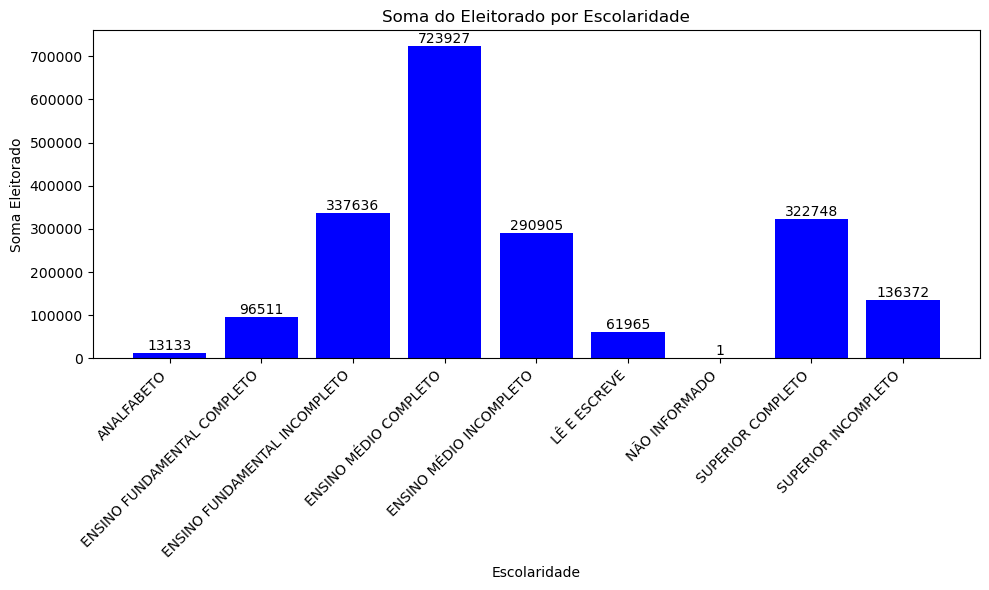

In [107]:
#Gerando grafico do total de escolaridade

# Configurações para exibir o gráfico de barras de forma mais agradável
plt.figure(figsize=(10, 6))
bars = plt.bar(somas_escolaridade["Escolaridade"], somas_escolaridade["Soma Eleitorado"], color='blue')

# Adicionando rótulos e título
plt.xlabel("Escolaridade")
plt.ylabel("Soma Eleitorado")
plt.title("Soma do Eleitorado por Escolaridade")

# Rotacionando os rótulos do eixo x para melhor legibilidade
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), ha='center', va='bottom', color='black', fontsize=10)

# Exibindo o gráfico
plt.tight_layout()
plt.show()


In [108]:
# Especifique o nome do arquivo Excel que você deseja criar
nome_do_arquivo = 'Total_escolaridade_salvador.xlsx'

# Exportar o DataFrame para o arquivo Excel
somas_escolaridade.to_excel(nome_do_arquivo, index=False)

In [109]:
### ZONAS E BAIRROS/ ESCOLARIDADE ################

In [110]:
#Unindo zonas e escolaridade
#eleitorado["Bairros_Zona"] = df1.apply(lambda row: df2[df2["Zona"] == 1]["Bairros_Agrupados"].values[0] if row["Zona"] == 1 else [], axis=1)
# Dicionário com mapeamento de zonas para bairros
zonas_bairros = dict(zip(zonas_eleitorais["Zona"], zonas_eleitorais["Bairros_Agrupados"]))

# Aplicar o mapeamento ao DataFrame
eleitorado["Bairros_Zona"] = eleitorado["Zona"].map(zonas_bairros)

# Exibindo o primeiro DataFrame com a nova coluna
display(eleitorado)

,Zona,Escolaridade,Eleitorado,Com biometria,Com biometria (%),Com nome social,Com deficiência,Data de carga,Bairros_Zona
0,1,ANALFABETO,233,194,"0,8326",0,21,2022-07-11 22:32:34,"[BARRA, CAMPO GRANDE, CANELA, GRAÇA, CHAME-CHA..."
1,1,ENSINO FUNDAMENTAL COMPLETO,2185,2038,"0,9327",2,43,2022-07-11 22:32:34,"[BARRA, CAMPO GRANDE, CANELA, GRAÇA, CHAME-CHA..."
2,1,ENSINO FUNDAMENTAL INCOMPLETO,5586,5293,"0,9475",5,96,2022-07-11 22:32:34,"[BARRA, CAMPO GRANDE, CANELA, GRAÇA, CHAME-CHA..."
3,1,ENSINO MÉDIO COMPLETO,19699,18461,"0,9372",18,195,2022-07-11 22:32:34,"[BARRA, CAMPO GRANDE, CANELA, GRAÇA, CHAME-CHA..."
4,1,ENSINO MÉDIO INCOMPLETO,6294,4911,"0,7803",7,57,2022-07-11 22:32:34,"[BARRA, CAMPO GRANDE, CANELA, GRAÇA, CHAME-CHA..."
...,...,...,...,...,...,...,...,...,...
148,19,ENSINO MÉDIO COMPLETO,51589,48505,"0,9402",26,430,2022-07-11 22:32:34,"[MUSSURUNGA II, MUSSURUNGA I, NOVA BRASÍLIA, C..."
149,19,ENSINO MÉDIO INCOMPLETO,20808,16708,"0,803",22,152,2022-07-11 22:32:34,"[MUSSURUNGA II, MUSSURUNGA I, NOVA BRASÍLIA, C..."
150,19,LÊ E ESCREVE,4287,4118,"0,9606",1,227,2022-07-11 22:32:34,"[MUSSURUNGA II, MUSSURUNGA I, NOVA BRASÍLIA, C..."
151,19,SUPERIOR COMPLETO,11073,10888,"0,9833",0,65,2022-07-11 22:32:34,"[MUSSURUNGA II, MUSSURUNGA I, NOVA BRASÍLIA, C..."


In [111]:
# Especifique o nome do arquivo Excel que você deseja criar
nome_do_arquivo = 'Escolaridade_cruzamento_bairros.xlsx'

# Exportar o DataFrame para o arquivo Excel
eleitorado.to_excel(nome_do_arquivo, index=False)

### Aplicando calculo a todas as zonas


In [112]:
categorias_escolaridade = ['ANALFABETO', 'ENSINO FUNDAMENTAL COMPLETO',
                          'ENSINO FUNDAMENTAL INCOMPLETO', 'ENSINO MÉDIO COMPLETO',
                          'ENSINO MÉDIO INCOMPLETO', 'LÊ E ESCREVE', 'NÃO INFORMADO',
                          'SUPERIOR COMPLETO', 'SUPERIOR INCOMPLETO']



In [113]:
categoria = "SUPERIOR INCOMPLETO"
data_novo_dataframe = {"Zona": [], f"Quantidade Categoria {categoria}": [], "Bairros_da_Zona": []}

# Definir a chave antes do loop
data_novo_dataframe[f"Quantidade Categoria {categoria}"] = []

# Loop pelas zonas
for zona in range(1, 20):
    df_zona = eleitorado[eleitorado["Zona"] == zona]
    df_categoria = df_zona[df_zona["Escolaridade"] == categoria]
    
    if not df_categoria.empty:
        quantidade_analfabetos_zona = df_categoria["Eleitorado"].sum()
        
        data_novo_dataframe["Zona"].append(zona)
        data_novo_dataframe[f"Quantidade Categoria {categoria}"].append(quantidade_analfabetos_zona)
        data_novo_dataframe["Bairros_da_Zona"].append(df_categoria["Bairros_Zona"].values[0])

# Criar o novo DataFrame
df_analfabeto_zonas = pd.DataFrame(data_novo_dataframe)

# Exibindo o novo DataFrame
display(df_analfabeto_zonas)




,Zona,Quantidade Categoria SUPERIOR INCOMPLETO,Bairros_da_Zona
0,1,7929,"[BARRA, CAMPO GRANDE, CANELA, GRAÇA, CHAME-CHA..."
1,2,7846,"[RIO VERMELHO, PARQUE SÃO BRÁS, ONDINA, FEDERA..."
2,3,5987,"[PERO VAZ, IAPI, FAZENDA GRANDE DO RETIRO, PAU..."
3,4,4470,"[PERIPERI, COUTOS, PARIPE, FAZENDA COUTOS, TUB..."
4,5,6299,"[CABULA, SÃO GONÇALO, SÃO GONÇALO DO RETIRO, M..."
5,6,8473,"[BROTAS, CAMPINAS DE BROTAS, BONOCÔ, BOA VISTA..."
6,7,8601,"[NAZARÉ, BARRIS, BARBALHO, SAÚDE, PITANGUEIRAS..."
7,8,4788,"[CAJAZEIRAS IV, CAJAZEIRAS V, CAJAZEIRAS VI, C..."
8,9,6728,"[ITAPAGIPE, RIBEIRA, BOA VIAGEM, BONFIM, URUGU..."
9,10,13994,"[IMBUÍ, BOCA DO RIO, BAIRRO DA PAZ, PITUAÇU, P..."


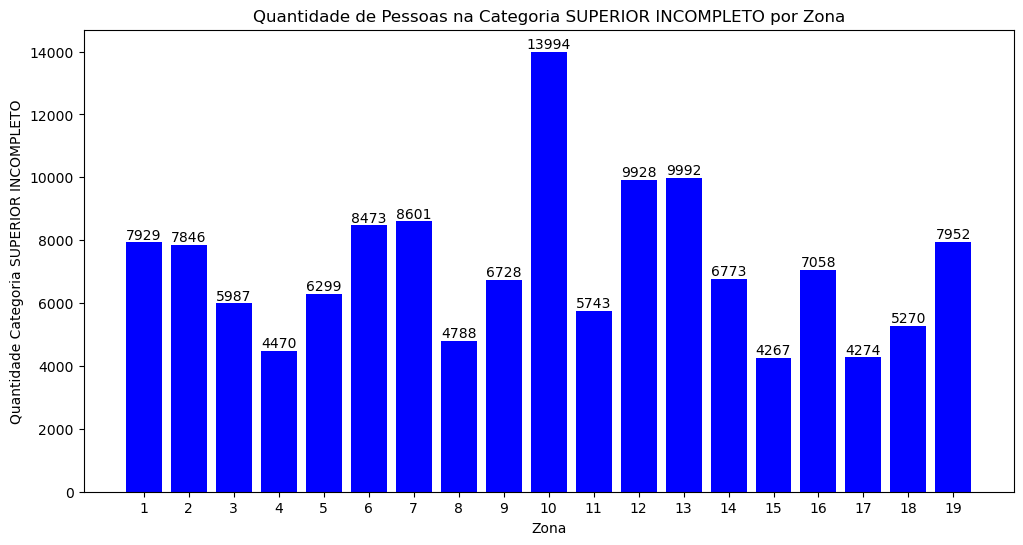

In [114]:


# Criar o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_analfabeto_zonas['Zona'], df_analfabeto_zonas[f'Quantidade Categoria {categoria}'], color='b')
plt.xlabel('Zona')
plt.ylabel(f'Quantidade Categoria {categoria}')
plt.title(f'Quantidade de Pessoas na Categoria {categoria} por Zona')

# Inserir os valores acima das barras
for i, valor in enumerate(df_analfabeto_zonas[f'Quantidade Categoria {categoria}']):
    plt.text(df_analfabeto_zonas['Zona'][i], valor + 10, str(valor), ha='center', va='bottom')

plt.xticks(df_analfabeto_zonas['Zona'])
plt.show()

In [115]:
total_por_zona = pd.read_csv('./zona-total.csv')
#total_por_zona.head()
#df = pd.DataFrame(total_por_zona)
#df.head()

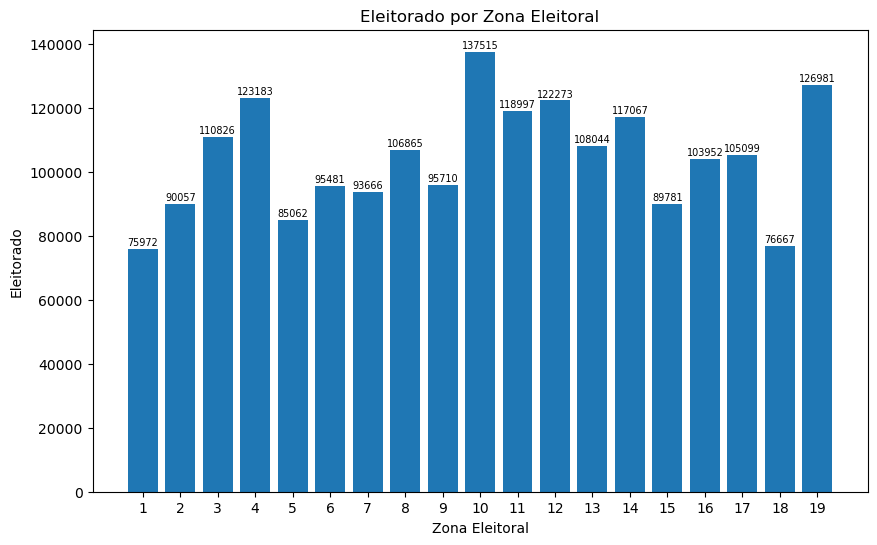

In [116]:
# Criar um DataFrame fictício com dados de 19 zonas eleitorais
df = pd.DataFrame(total_por_zona)
df['Zona'] = df['Zona'].astype(int)
# Plotar o gráfico de barras
plt.figure(figsize=(10, 6))
bars = plt.bar(df['Zona'], df['Eleitorado'])
plt.xlabel('Zona Eleitoral')
plt.ylabel('Eleitorado')
plt.title('Eleitorado por Zona Eleitoral')
plt.xticks(df['Zona'])

# Adicionar os valores acima das barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, int(yval), ha='center', va='bottom',fontsize=7)


## Escolaridade - Zonas - Idade



In [117]:
eleitorado_idade_genero = pd.read_csv('./cruzamento_genero_idade.csv')
display(eleitorado_idade_genero)

,Zona,Escolaridade,Gênero,Faixa etária,Eleitorado,Com biometria,Com biometria (%),Com nome social,Com deficiência,Data de carga
0,1,ANALFABETO,FEMININO,21 a 24 anos,1,0,0,0,0,2022-07-11 22:32:34
1,1,ANALFABETO,FEMININO,25 a 29 anos,2,1,"0,5",0,0,2022-07-11 22:32:34
2,1,ANALFABETO,FEMININO,30 a 34 anos,4,3,"0,75",0,0,2022-07-11 22:32:34
3,1,ANALFABETO,FEMININO,35 a 39 anos,2,1,"0,5",0,0,2022-07-11 22:32:34
4,1,ANALFABETO,FEMININO,40 a 44 anos,5,4,"0,8",0,1,2022-07-11 22:32:34
...,...,...,...,...,...,...,...,...,...,...
5883,19,SUPERIOR INCOMPLETO,MASCULINO,60 a 64 anos,73,72,"0,9863",0,0,2022-07-11 22:32:34
5884,19,SUPERIOR INCOMPLETO,MASCULINO,65 a 69 anos,53,52,"0,9811",0,2,2022-07-11 22:32:34
5885,19,SUPERIOR INCOMPLETO,MASCULINO,70 a 74 anos,26,25,"0,9615",0,1,2022-07-11 22:32:34
5886,19,SUPERIOR INCOMPLETO,MASCULINO,75 a 79 anos,6,6,1,0,0,2022-07-11 22:32:34


In [118]:
faixas_etarias_1 = eleitorado_idade_genero['Faixa etária'].unique()
faixas_etarias = ['16 anos', '17 anos', '18 anos','19 anos','20 anos','21 a 24 anos','25 a 29 anos', '30 a 34 anos', '35 a 39 anos',
       '40 a 44 anos', '45 a 49 anos', '50 a 54 anos', '55 a 59 anos',
       '60 a 64 anos', '65 a 69 anos', '70 a 74 anos', '75 a 79 anos',
       '80 a 84 anos', '85 a 89 anos', '90 a 94 anos','95 a 99 anos', '100 anos ou mais', 'Inválido']

In [119]:
# Inicialize um dicionário para armazenar os dados reestruturados
dados_reestruturados = {'Escolaridade': [], 'Faixas Etárias': [], 'Total Eleitorado': []}

# Iterar pelas escolaridades
for escolaridade in escolaridades:
    # Adicionar a escolaridade ao dicionário de dados reestruturados
    dados_reestruturados['Escolaridade'].extend([escolaridade] * len(faixas_etarias))
    
    # Iterar pelas faixas etárias
    for faixa_etaria in faixas_etarias:
        # Filtrar o conjunto de dados original para a faixa etária e escolaridade atuais
        dados_filtrados = eleitorado_idade_genero[(eleitorado_idade_genero['Faixa etária'] == faixa_etaria) &
                                                  (eleitorado_idade_genero['Escolaridade'] == escolaridade)]
        
        # Calcular o total de eleitores para a combinação atual
        total_eleitorado = dados_filtrados['Eleitorado'].sum()
        
        # Adicionar a faixa etária e o total de eleitorado ao dicionário de dados reestruturados
        dados_reestruturados['Faixas Etárias'].append(faixa_etaria)
        dados_reestruturados['Total Eleitorado'].append(total_eleitorado)

# Criar um novo DataFrame a partir dos dados reestruturados
novo_df = pd.DataFrame(dados_reestruturados)

novo_df


,Escolaridade,Faixas Etárias,Total Eleitorado
0,ANALFABETO,16 anos,4
1,ANALFABETO,17 anos,12
2,ANALFABETO,18 anos,21
3,ANALFABETO,19 anos,34
4,ANALFABETO,20 anos,31
...,...,...,...
202,SUPERIOR INCOMPLETO,85 a 89 anos,79
203,SUPERIOR INCOMPLETO,90 a 94 anos,17
204,SUPERIOR INCOMPLETO,95 a 99 anos,2
205,SUPERIOR INCOMPLETO,100 anos ou mais,0


### Escolaridade - Idade (filtro)

In [120]:
dados_analfabetos = novo_df[novo_df['Escolaridade'] == 'ANALFABETO']
dados_analfabetos

,Escolaridade,Faixas Etárias,Total Eleitorado
0,ANALFABETO,16 anos,4
1,ANALFABETO,17 anos,12
2,ANALFABETO,18 anos,21
3,ANALFABETO,19 anos,34
4,ANALFABETO,20 anos,31
5,ANALFABETO,21 a 24 anos,210
6,ANALFABETO,25 a 29 anos,308
7,ANALFABETO,30 a 34 anos,305
8,ANALFABETO,35 a 39 anos,448
9,ANALFABETO,40 a 44 anos,653


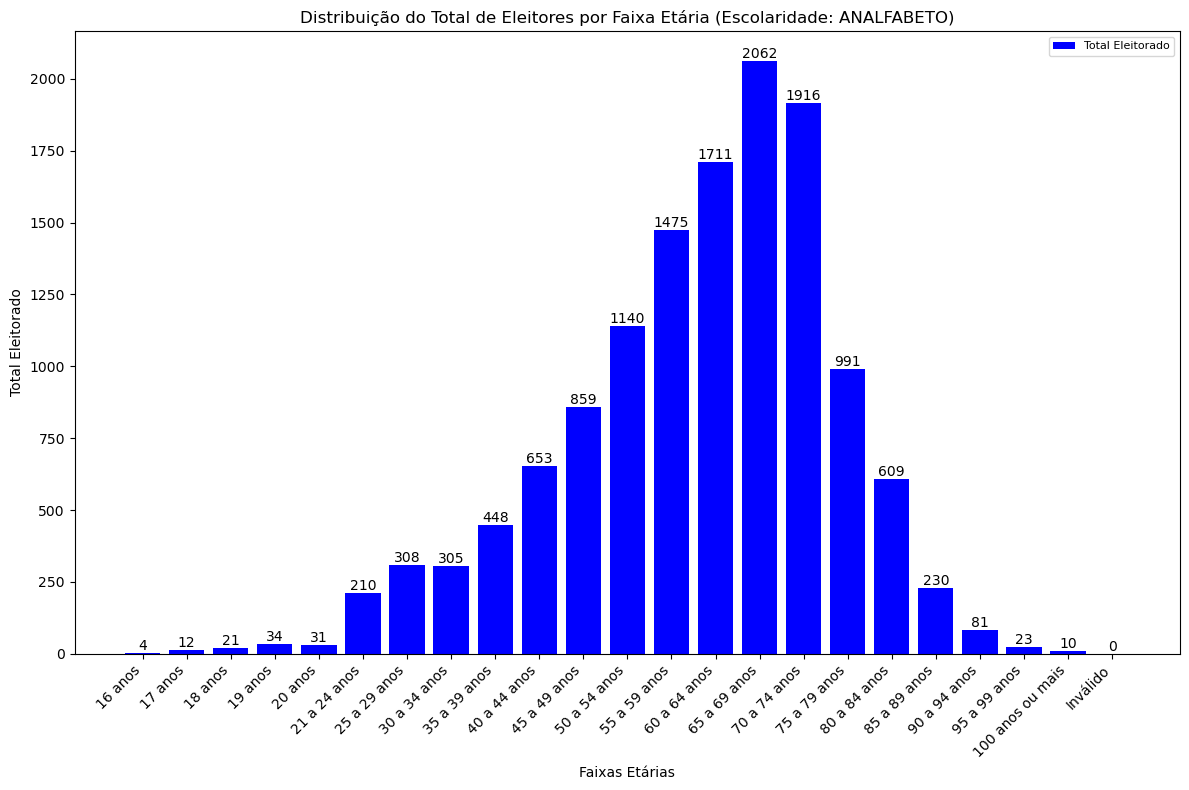

In [121]:

# Criar um gráfico de barras empilhadas
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_analfabetos['Faixas Etárias'], dados_analfabetos['Total Eleitorado'], label='Total Eleitorado', color='b')

# Adicionar rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: ANALFABETO)')

# Adicionar os valores em cima de cada barra
for bar, value in zip(bars, dados_analfabetos['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

# Rotacionar os rótulos do eixo x para melhor legibilidade
plt.xticks(rotation=45, ha='right')

# Ajustar o tamanho da fonte da legenda das faixas etárias
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [122]:
dados_fundamental_incompleto = novo_df[novo_df['Escolaridade'] == 'ENSINO FUNDAMENTAL INCOMPLETO']
dados_fundamental_incompleto

,Escolaridade,Faixas Etárias,Total Eleitorado
46,ENSINO FUNDAMENTAL INCOMPLETO,16 anos,1019
47,ENSINO FUNDAMENTAL INCOMPLETO,17 anos,1244
48,ENSINO FUNDAMENTAL INCOMPLETO,18 anos,1579
49,ENSINO FUNDAMENTAL INCOMPLETO,19 anos,2361
50,ENSINO FUNDAMENTAL INCOMPLETO,20 anos,3073
51,ENSINO FUNDAMENTAL INCOMPLETO,21 a 24 anos,22273
52,ENSINO FUNDAMENTAL INCOMPLETO,25 a 29 anos,25490
53,ENSINO FUNDAMENTAL INCOMPLETO,30 a 34 anos,21165
54,ENSINO FUNDAMENTAL INCOMPLETO,35 a 39 anos,26823
55,ENSINO FUNDAMENTAL INCOMPLETO,40 a 44 anos,35661


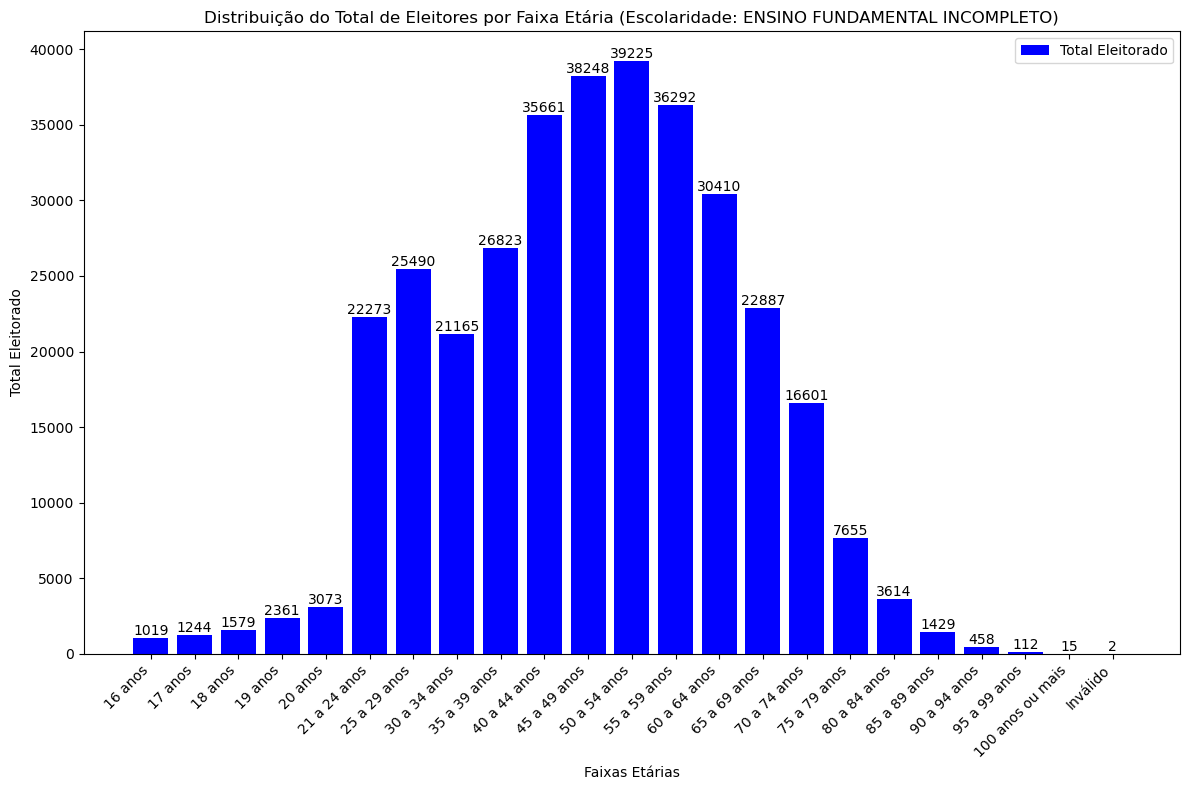

In [123]:

# Criar um gráfico 
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_fundamental_incompleto['Faixas Etárias'], dados_fundamental_incompleto['Total Eleitorado'], label='Total Eleitorado', color='b')

#rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: ENSINO FUNDAMENTAL INCOMPLETO)')

# valores em cima de cada barra
for bar, value in zip(bars, dados_fundamental_incompleto['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [124]:
dados_fundamental_completo = novo_df[novo_df['Escolaridade'] == 'ENSINO FUNDAMENTAL COMPLETO']
dados_fundamental_completo

,Escolaridade,Faixas Etárias,Total Eleitorado
23,ENSINO FUNDAMENTAL COMPLETO,16 anos,569
24,ENSINO FUNDAMENTAL COMPLETO,17 anos,771
25,ENSINO FUNDAMENTAL COMPLETO,18 anos,794
26,ENSINO FUNDAMENTAL COMPLETO,19 anos,765
27,ENSINO FUNDAMENTAL COMPLETO,20 anos,836
28,ENSINO FUNDAMENTAL COMPLETO,21 a 24 anos,4165
29,ENSINO FUNDAMENTAL COMPLETO,25 a 29 anos,5199
30,ENSINO FUNDAMENTAL COMPLETO,30 a 34 anos,5407
31,ENSINO FUNDAMENTAL COMPLETO,35 a 39 anos,7197
32,ENSINO FUNDAMENTAL COMPLETO,40 a 44 anos,9048


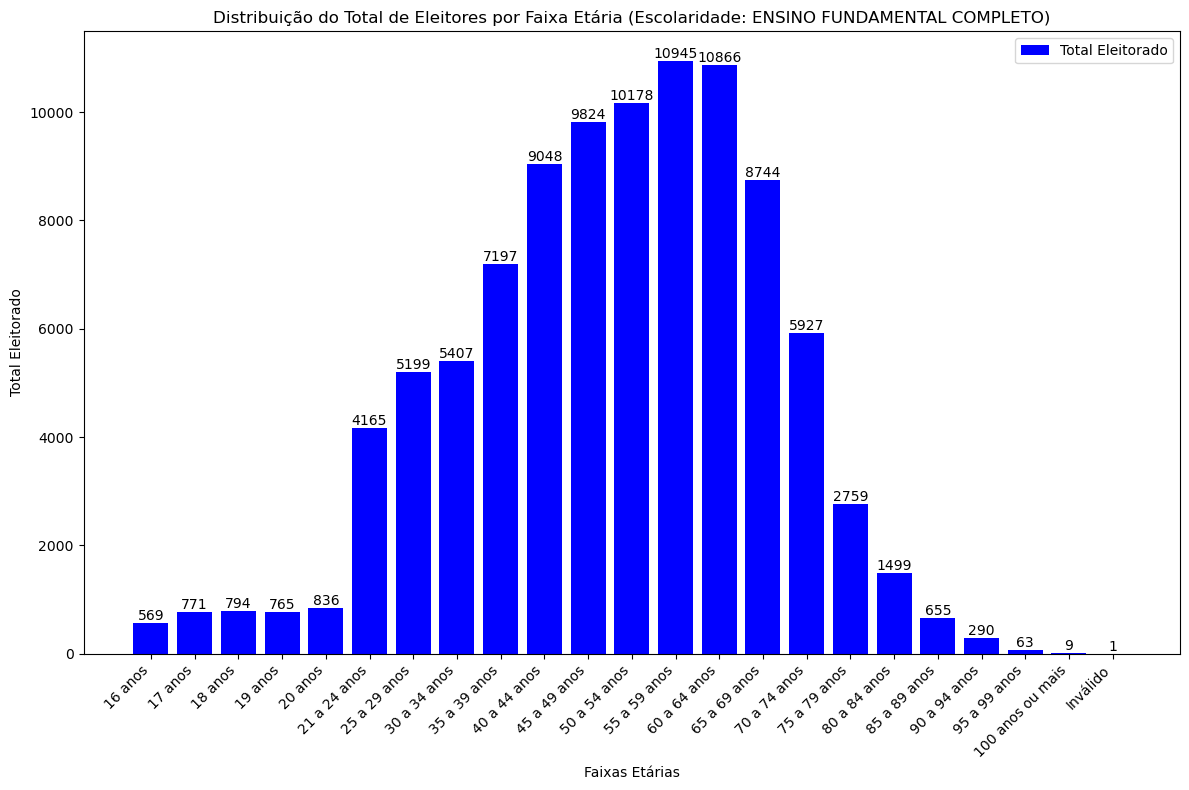

In [125]:

# Criar um gráfico 
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_fundamental_completo['Faixas Etárias'], dados_fundamental_completo['Total Eleitorado'], label='Total Eleitorado', color='b')

#rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: ENSINO FUNDAMENTAL COMPLETO)')

# valores em cima de cada barra
for bar, value in zip(bars, dados_fundamental_completo['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [126]:
dados_medio_completo = novo_df[novo_df['Escolaridade'] == 'ENSINO MÉDIO COMPLETO']
dados_medio_completo

,Escolaridade,Faixas Etárias,Total Eleitorado
69,ENSINO MÉDIO COMPLETO,16 anos,156
70,ENSINO MÉDIO COMPLETO,17 anos,820
71,ENSINO MÉDIO COMPLETO,18 anos,7009
72,ENSINO MÉDIO COMPLETO,19 anos,9222
73,ENSINO MÉDIO COMPLETO,20 anos,10189
74,ENSINO MÉDIO COMPLETO,21 a 24 anos,43798
75,ENSINO MÉDIO COMPLETO,25 a 29 anos,77987
76,ENSINO MÉDIO COMPLETO,30 a 34 anos,75210
77,ENSINO MÉDIO COMPLETO,35 a 39 anos,94353
78,ENSINO MÉDIO COMPLETO,40 a 44 anos,97129


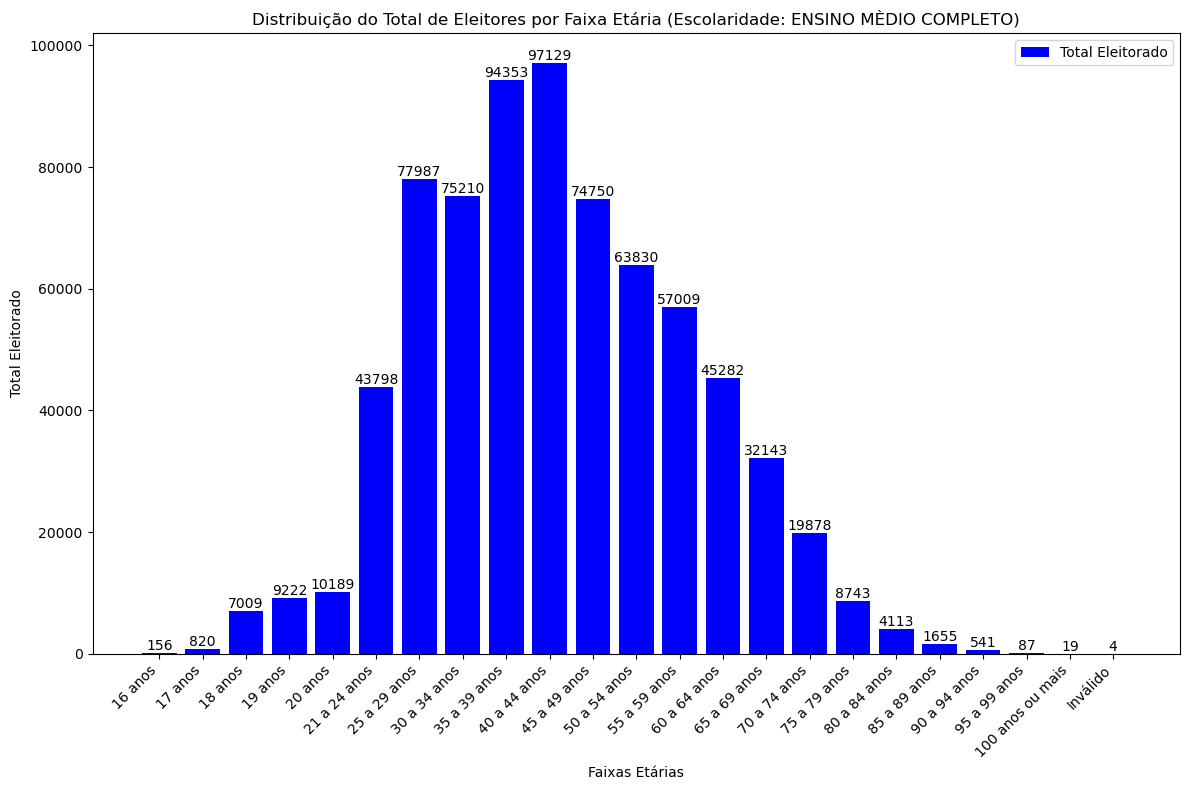

In [127]:

# Criar um gráfico 
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_medio_completo['Faixas Etárias'], dados_medio_completo['Total Eleitorado'], label='Total Eleitorado', color='b')

#rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: ENSINO MÈDIO COMPLETO)')

# valores em cima de cada barra
for bar, value in zip(bars, dados_medio_completo['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [128]:
dados_medio_incompleto = novo_df[novo_df['Escolaridade'] == 'ENSINO MÉDIO INCOMPLETO']
dados_medio_incompleto

,Escolaridade,Faixas Etárias,Total Eleitorado
92,ENSINO MÉDIO INCOMPLETO,16 anos,6909
93,ENSINO MÉDIO INCOMPLETO,17 anos,11313
94,ENSINO MÉDIO INCOMPLETO,18 anos,12597
95,ENSINO MÉDIO INCOMPLETO,19 anos,11423
96,ENSINO MÉDIO INCOMPLETO,20 anos,12712
97,ENSINO MÉDIO INCOMPLETO,21 a 24 anos,63336
98,ENSINO MÉDIO INCOMPLETO,25 a 29 anos,37112
99,ENSINO MÉDIO INCOMPLETO,30 a 34 anos,22293
100,ENSINO MÉDIO INCOMPLETO,35 a 39 anos,24371
101,ENSINO MÉDIO INCOMPLETO,40 a 44 anos,22552


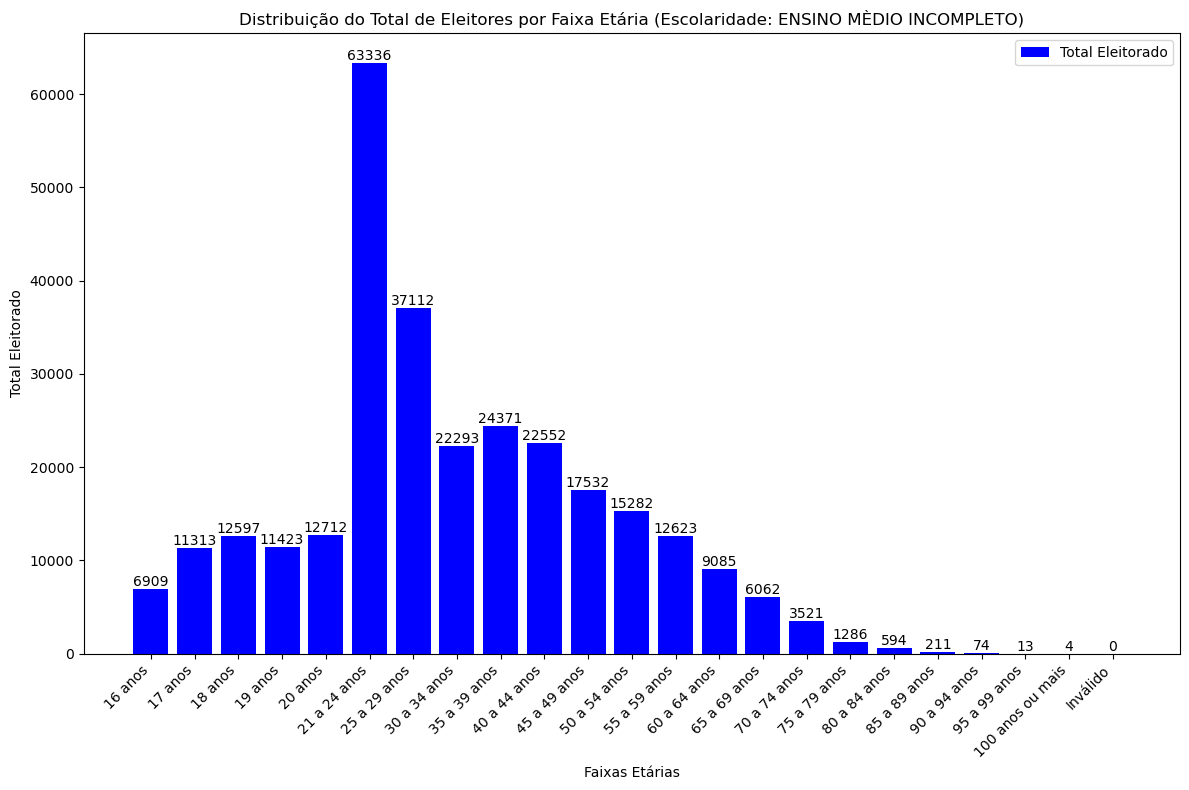

In [129]:

# Criar um gráfico 
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_medio_incompleto['Faixas Etárias'], dados_medio_incompleto['Total Eleitorado'], label='Total Eleitorado', color='b')

#rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: ENSINO MÈDIO INCOMPLETO)')

# valores em cima de cada barra
for bar, value in zip(bars, dados_medio_incompleto['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [130]:
dados_le_escreve = novo_df[novo_df['Escolaridade'] == 'LÊ E ESCREVE']
dados_le_escreve 

,Escolaridade,Faixas Etárias,Total Eleitorado
115,LÊ E ESCREVE,16 anos,48
116,LÊ E ESCREVE,17 anos,93
117,LÊ E ESCREVE,18 anos,100
118,LÊ E ESCREVE,19 anos,109
119,LÊ E ESCREVE,20 anos,121
120,LÊ E ESCREVE,21 a 24 anos,525
121,LÊ E ESCREVE,25 a 29 anos,784
122,LÊ E ESCREVE,30 a 34 anos,861
123,LÊ E ESCREVE,35 a 39 anos,1642
124,LÊ E ESCREVE,40 a 44 anos,2950


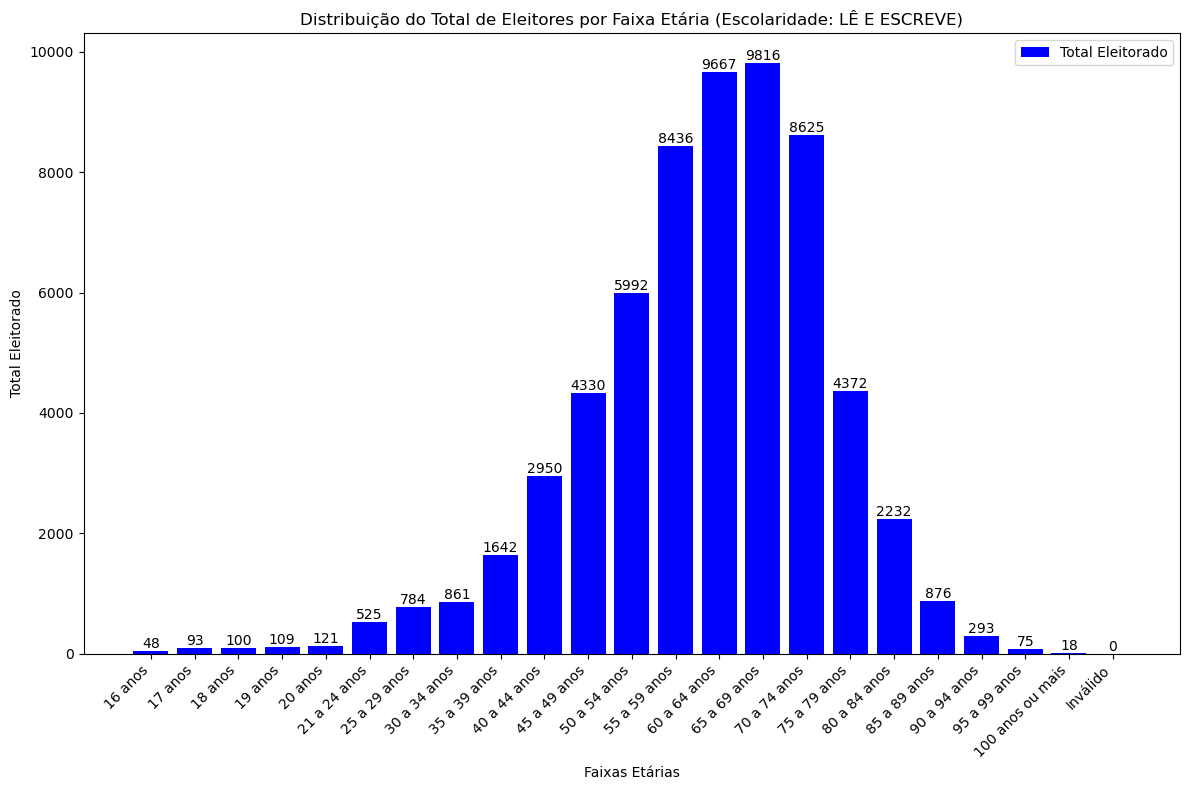

In [131]:

# Criar um gráfico 
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_le_escreve ['Faixas Etárias'],dados_le_escreve['Total Eleitorado'], label='Total Eleitorado', color='b')

#rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: LÊ E ESCREVE)')

# valores em cima de cada barra
for bar, value in zip(bars, dados_le_escreve['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [132]:
dados_superior_completo = novo_df[novo_df['Escolaridade'] == 'SUPERIOR COMPLETO']
dados_superior_completo 

,Escolaridade,Faixas Etárias,Total Eleitorado
161,SUPERIOR COMPLETO,16 anos,1
162,SUPERIOR COMPLETO,17 anos,5
163,SUPERIOR COMPLETO,18 anos,25
164,SUPERIOR COMPLETO,19 anos,35
165,SUPERIOR COMPLETO,20 anos,45
166,SUPERIOR COMPLETO,21 a 24 anos,641
167,SUPERIOR COMPLETO,25 a 29 anos,11494
168,SUPERIOR COMPLETO,30 a 34 anos,37589
169,SUPERIOR COMPLETO,35 a 39 anos,54075
170,SUPERIOR COMPLETO,40 a 44 anos,55302


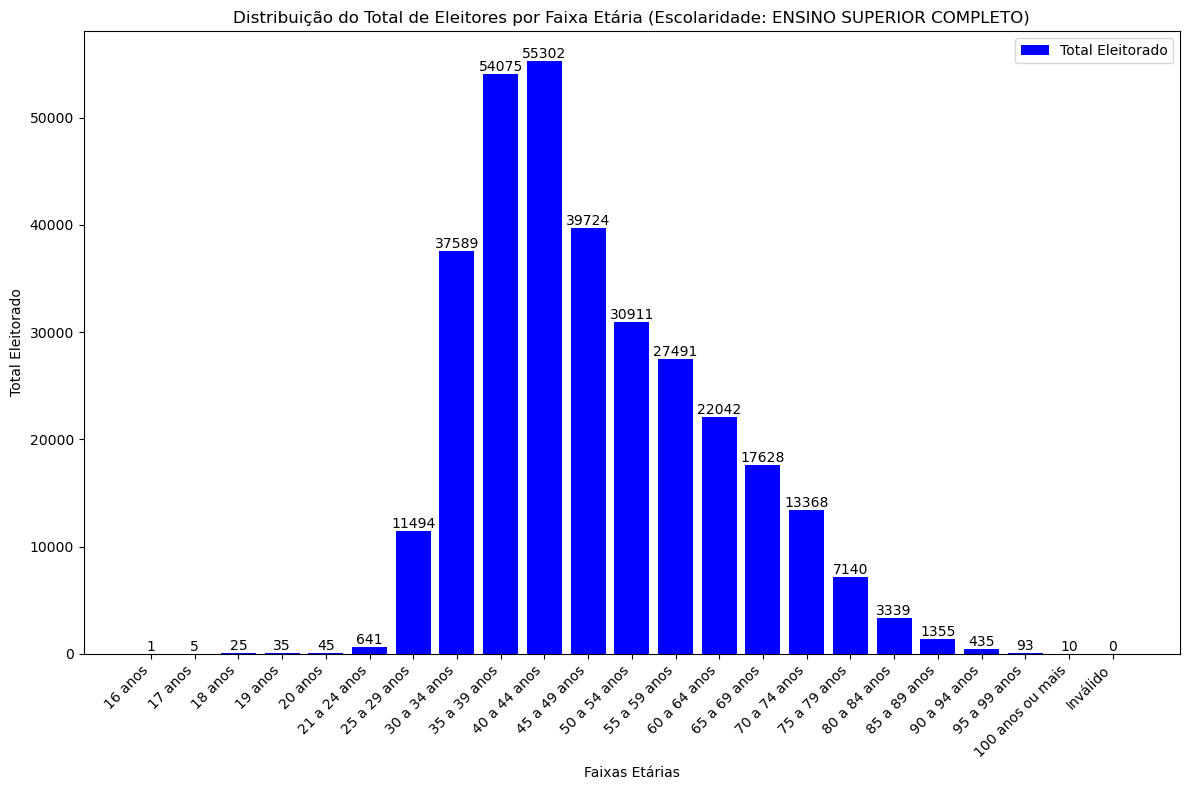

In [133]:

# Criar um gráfico 
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_superior_completo['Faixas Etárias'],dados_superior_completo['Total Eleitorado'], label='Total Eleitorado', color='b')

#rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: ENSINO SUPERIOR COMPLETO)')

# valores em cima de cada barra
for bar, value in zip(bars, dados_superior_completo['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [134]:
dados_superior_incompleto = novo_df[novo_df['Escolaridade'] == 'SUPERIOR INCOMPLETO']
dados_superior_incompleto 

,Escolaridade,Faixas Etárias,Total Eleitorado
184,SUPERIOR INCOMPLETO,16 anos,21
185,SUPERIOR INCOMPLETO,17 anos,78
186,SUPERIOR INCOMPLETO,18 anos,724
187,SUPERIOR INCOMPLETO,19 anos,1396
188,SUPERIOR INCOMPLETO,20 anos,1923
189,SUPERIOR INCOMPLETO,21 a 24 anos,11483
190,SUPERIOR INCOMPLETO,25 a 29 anos,34058
191,SUPERIOR INCOMPLETO,30 a 34 anos,22193
192,SUPERIOR INCOMPLETO,35 a 39 anos,18202
193,SUPERIOR INCOMPLETO,40 a 44 anos,14926


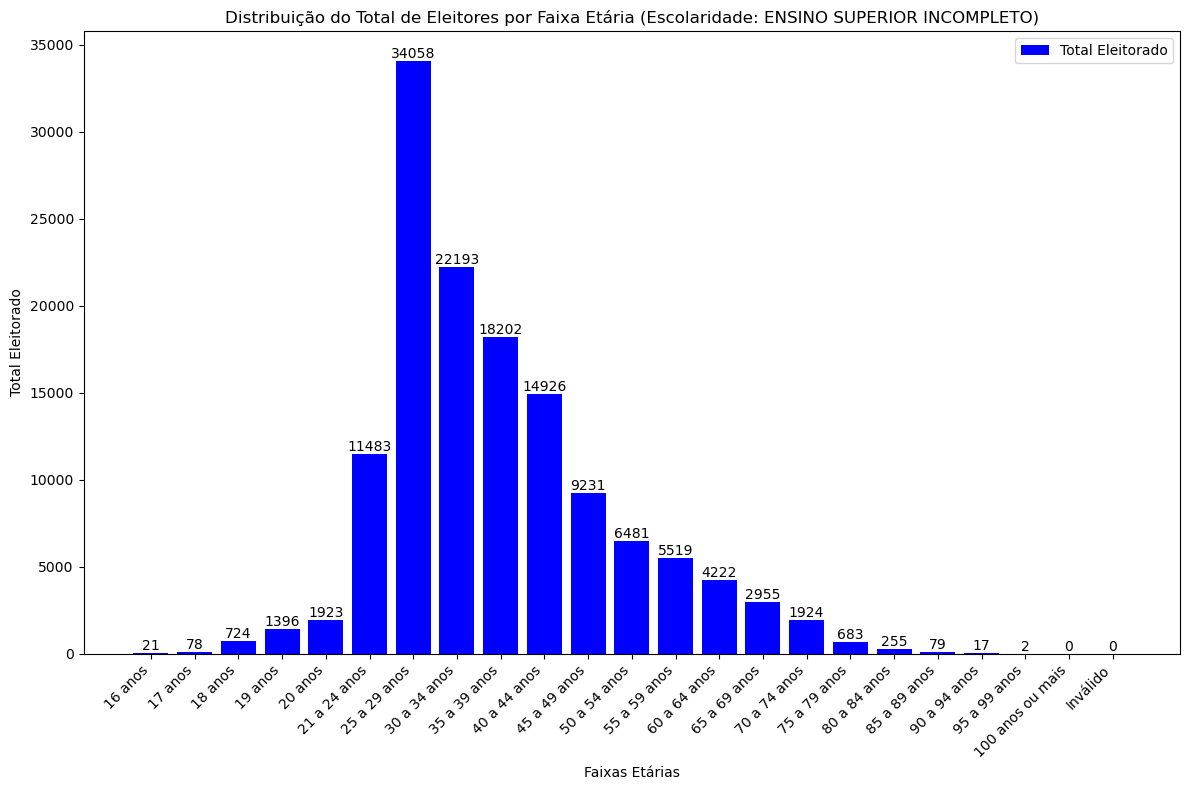

In [135]:

# Criar um gráfico 
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(dados_superior_incompleto['Faixas Etárias'],dados_superior_incompleto['Total Eleitorado'], label='Total Eleitorado', color='b')

#rótulos e título
ax.set_xlabel('Faixas Etárias')
ax.set_ylabel('Total Eleitorado')
ax.set_title('Distribuição do Total de Eleitores por Faixa Etária (Escolaridade: ENSINO SUPERIOR INCOMPLETO)')

# valores em cima de cada barra
for bar, value in zip(bars, dados_superior_incompleto['Total Eleitorado']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value), ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Genero


In [136]:
genero = pd.read_csv('./genero.csv')
display(genero)

,Escolaridade,Gênero,Eleitorado,Com biometria,Com biometria (%),Com nome social,Com deficiência,Data de carga
0,ANALFABETO,FEMININO,8191,7660,"0,9352",1,814,2022-07-11 22:32:34
1,ANALFABETO,MASCULINO,4942,4273,"0,8646",1,749,2022-07-11 22:32:34
2,ENSINO FUNDAMENTAL COMPLETO,FEMININO,47765,45029,"0,9427",23,754,2022-07-11 22:32:34
3,ENSINO FUNDAMENTAL COMPLETO,MASCULINO,48746,45988,"0,9434",18,769,2022-07-11 22:32:34
4,ENSINO FUNDAMENTAL INCOMPLETO,FEMININO,174924,168773,"0,9648",48,2871,2022-07-11 22:32:34
5,ENSINO FUNDAMENTAL INCOMPLETO,MASCULINO,162712,153137,"0,9412",38,2641,2022-07-11 22:32:34
6,ENSINO MÉDIO COMPLETO,FEMININO,409330,387131,"0,9458",148,2879,2022-07-11 22:32:34
7,ENSINO MÉDIO COMPLETO,MASCULINO,314597,296533,"0,9426",130,2163,2022-07-11 22:32:34
8,ENSINO MÉDIO INCOMPLETO,FEMININO,150105,121810,"0,8115",154,817,2022-07-11 22:32:34
9,ENSINO MÉDIO INCOMPLETO,MASCULINO,140800,114958,"0,8165",130,946,2022-07-11 22:32:34


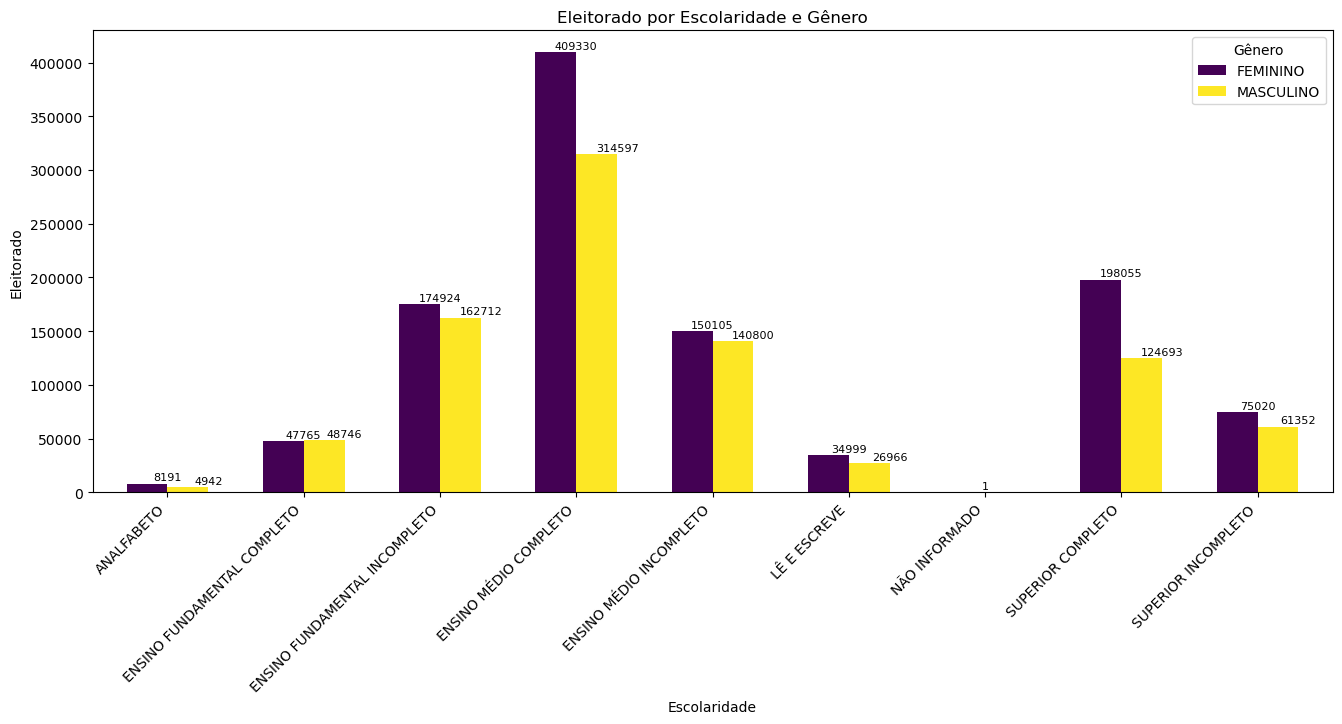

In [137]:
# Agrupar os dados por escolaridade e gênero, e calcular a soma do eleitorado
df_grouped = genero.groupby(['Escolaridade', 'Gênero'])['Eleitorado'].sum().unstack()

# Criar gráfico de barras
fig, ax = plt.subplots(figsize=(16, 6))  # Ajuste o tamanho da figura conforme necessário (largura, altura)

# Adicionar rótulos com os valores (sem vírgulas)
for idx, (escolaridade, row) in enumerate(df_grouped.iterrows()):
    for gender, value in row.items():
        if not pd.isnull(value):
            x = idx if gender == 'FEMININO' else idx + 0.3  # Ajuste para separar as barras de FEMININO e MASCULINO
            ax.text(x, value + 1000, f'{int(value)}', ha='center', va='bottom' ,fontsize=8)

# Configurar o gráfico
df_grouped.plot(kind='bar', width=0.6, colormap='viridis', ax=ax)

ax.set_xlabel('Escolaridade')
ax.set_ylabel('Eleitorado')
ax.set_title('Eleitorado por Escolaridade e Gênero')
plt.xticks(rotation=45, ha='right')
# Mostrar o gráfico
plt.show()
